In [1]:
import os
import time
import glob
import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.table import Table
from astropy.coordinates import SkyCoord

import importlib
import numpy as np
import pandas as pd
from math import floor

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection

from scipy.optimize import minimize

In [2]:
import sys
sys.path.append('observing-program/py')
import grism_dispersion
import footprintutils as fp
import roman_coords_transform as ctrans

In [3]:
code_data_dir = 'observing-program/data/'
rctrans = ctrans.RomanCoordsTransform(file_path=code_data_dir)

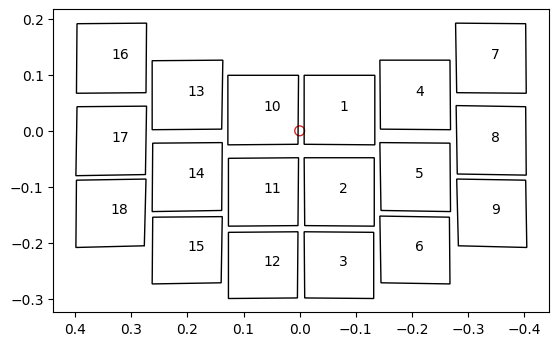

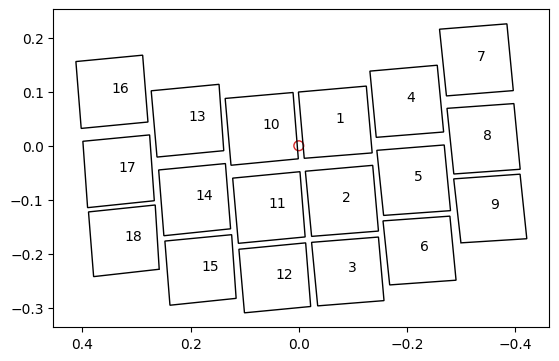

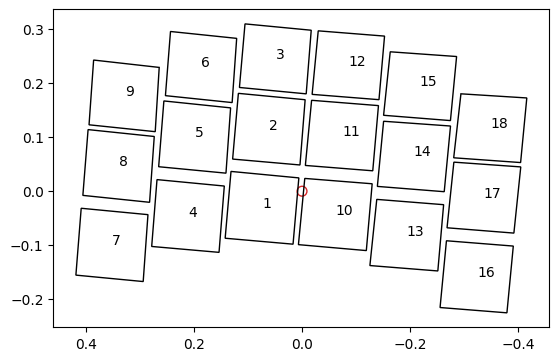

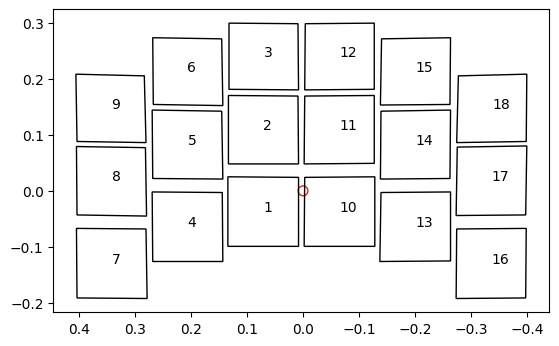

In [72]:
RA_list = [0]
Dec_list = [0]
PA_list = [0, 5, 175, 180]
pointing_coords = []
for r in RA_list:
  for d in Dec_list:
    for p in PA_list:
      pointing_coords.append([r,d,p])

footprints = {}
for i in range(len(pointing_coords)):
  RA = pointing_coords[i][0]
  Dec = pointing_coords[i][1]
  PA = pointing_coords[i][2]
  dfoot = rctrans.wfi_sky_pointing(RA, Dec, PA, ds9=False)
  footprints[i] = dfoot[0]

In [73]:
##sim parameters
ns = 10000 # initial number of stars
exp = np.arange(len(footprints))
Nexp = len(exp)

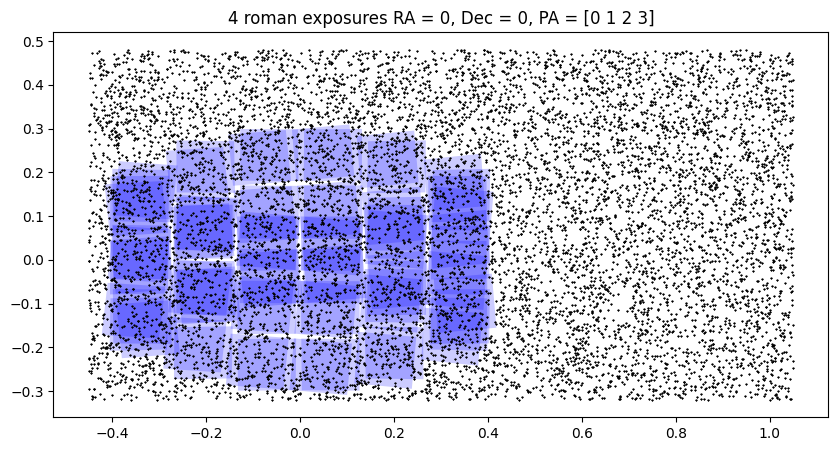

In [74]:

fig, ax = plt.subplots(figsize = (10,5))
for footprint in range(len(footprints)):
  for detector in range(1,19):
    corners = footprints[footprint][detector]['vertices']

    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')

    ax.add_patch(polygon)

plt.title("4 roman exposures RA = 0, Dec = 0, PA = {}".format(exp))

stars_x = (np.random.rand(ns) - 0.3)*1.5
stars_y = (np.random.rand(ns) - 0.4)*0.8

plt.plot(stars_x, stars_y, "*", color = "black", markersize = 1)
plt.show()

In [75]:
#create lists of paths for exposures

stars = np.zeros((ns,2))
stars[:,0] = stars_x
stars[:,1] = stars_y

select_exposure = {}

for footprint in exp:
  temp_paths = []
  temp_ond = np.array([False]*ns)
  for detector in range(1,19):
    corners = footprints[footprint][detector]['vertices']
    verts = np.concatenate((corners, [corners[0]]))
    path = Path(verts)
    footprints[footprint][detector]['path'] = path
    temp_paths.append(path)
  for tpath in temp_paths:
    ondetector = tpath.contains_points(stars)
    temp_ond += ondetector
  footprints[footprint]
  select_exposure[footprint] = temp_ond



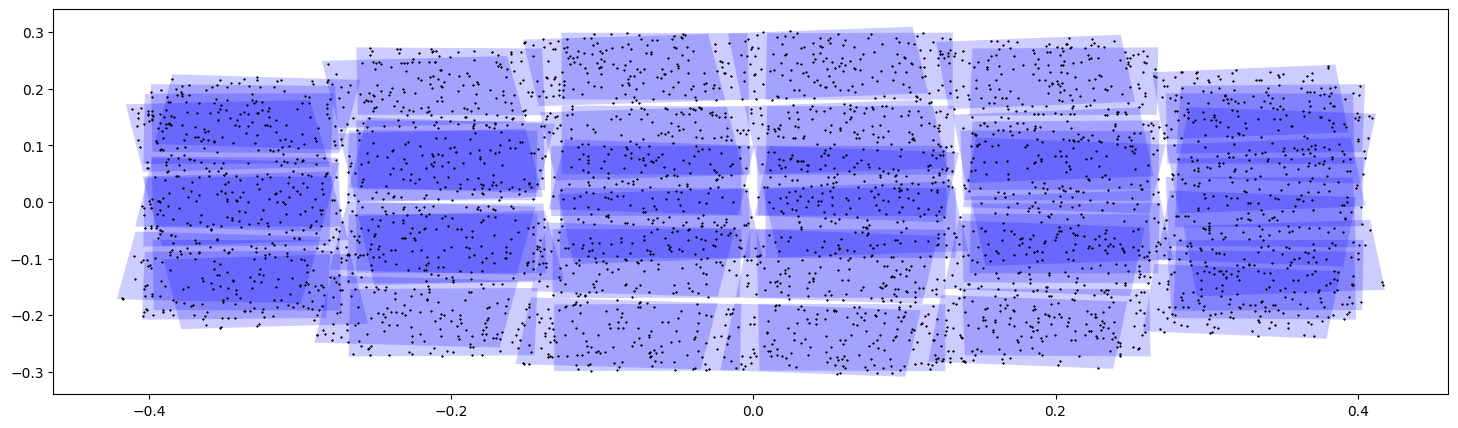

In [76]:
select_observed = np.array([False]*ns)
for footprint in exp:
  select_observed += select_exposure[footprint]
ns_obs = np.sum(select_observed)
stars_obs = stars[select_observed]

select_obs_exposure = {}
for footprint in exp:
  select_obs_exposure[footprint] = select_exposure[footprint][select_observed]

# Create a figure and an axes
fig, ax = plt.subplots(figsize = (18,5))
for footprint in exp:
  for detector in range(1,19):
    corners = footprints[footprint][detector]['vertices']
    polygon = patches.Polygon(corners, closed=True, alpha = 0.2, facecolor = 'blue')
    ax.add_patch(polygon)

plt.plot(stars_obs[:,0], stars_obs[:,1], "*", color = "black", markersize = 1)
# Display the plot
plt.show()

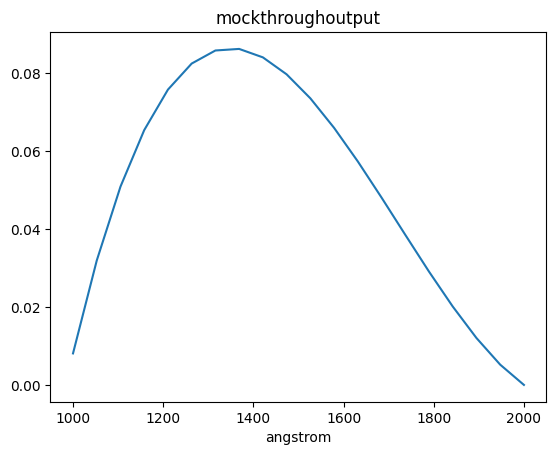

In [77]:
def throughput(x):
    coeff = [0.4, -0.9, -2.7, 3.3]
    scale = 1
    terms = [coeff[i]*x**(3-i) for i in range(4)]
    return scale*sum(terms)

lam = np.linspace(-2.5,2,20)
rescaled = (throughput(lam)-np.min(throughput(lam))) / np.sum((throughput(lam)-np.min(throughput(lam))))
lam_range = np.linspace(1000,2000,20)
plt.plot(lam_range, rescaled)
plt.title("mockthroughoutput")
plt.xlabel("angstrom")
plt.show()

In [145]:
#im gonna assume an arbitrary sigma k here
np.random.seed(17)
sigk = 0.1
sig_star = 0.5
true_k = np.random.normal(0,sigk**2,len(exp))
true_brightness = np.random.normal(1.0,sig_star**2,len(stars_obs))
sig_ij = 0.01
sig_lam = 0.1

true_k -= np.mean(true_k)
Nstars  = stars_obs.shape[0] #observed number of stars


# exists_in_exp[i, j] is True if star j is observed in any detector of exp[i].
exists_in_exp = np.zeros((Nexp, Nstars), dtype=bool)

for i in exp:
    mask = np.zeros(Nstars, dtype=bool) #initialise all false
    for det_id in range(1, 19): 
        #loop through every detector (theres probably a faster way to do this)
        #do path contains points for each exposure
        path = footprints[i][det_id]['path']
        mask |= path.contains_points(stars_obs)      
    exists_in_exp[i] = mask
    
# now for a row i, you have a mask to select stars that are observed by it
# and for a column j, you have a mask that selects exposures that contain star j
# this is a useful mask to generate m_ij

m_ij = [true_brightness for _ in range(Nexp)]
m_ij = np.array(m_ij)
m_ij = np.where(exists_in_exp, true_brightness - true_k[:,None], 0.0)

m_lamij = [m_ij]*len(rescaled)
m_lamij *= rescaled[:, None, None] 
# mask = (m_lamij != 0)
# error_array = np.random.normal(0,0.005,size = m_lamij.shape)
# error_array *= mask
# m_lamij += error_array


# 0: wavelength
# 1: exposure
# 2: star


In [136]:
# For each star j, collect the list of exposures containing it 
# in_exp is a list of length Nstars, each element a list of exposures (differing lengths!)
in_exp = [
    [exp[i] for i in np.nonzero(exists_in_exp[:, j])[0]]
    for j in range(Nstars)
]

# Find unique overlap patterns using set, and discard those of length 1 (can't use stars that are only observed once)
unique_patterns = {
    tuple(lst) for lst in in_exp
    if len(lst) > 1
}
overlaps = [list(pat) for pat in unique_patterns]


# For each overlap pattern, build a boolean mask (length Nstars)
# that is True exactly where in_detector[j] == that pattern.
select_overlaps = []
for pat in overlaps:
    # build a boolean array of shape (Nexp,) marking which exposures are in this pattern
    pat_mask = np.isin(exp, pat)
    # compare full exists_in_exp against this mask column-wise, so for each star, if the pattern in exists_in_exp matches True, else False
    star_mask = np.all(exists_in_exp == pat_mask[:, None], axis=0)
    # so for e
    # print(star_mask.shape)
    select_overlaps.append(star_mask)

# select_overlaps[l][j] is true if star j belongs to overlap l
# shape (Nl, Nstars)


In [137]:
select_overlaps = np.array(select_overlaps)
select_overlaps.shape

(11, 3701)

In [138]:
Nl = len(overlaps)
Nstarl = np.array([len(stars_obs[select_overlaps[l]]) for l in range(Nl)])

m_il = np.zeros((len(exp), Nl))#this could probably be optimised like m_ij
for i in range(len(exp)):
  for l in range(Nl):
    m_il[i,l] = np.mean(m_ij[i,:][select_overlaps[l]])

In [139]:
def chi2J_vec(ki, m_ij, sig_j, sigk):
    """
    ki:   shape (Nd,)
    m_ij: shape (Nd, Nj)
    sig_j: scalar
    sigk: scalar
    """
    nonzero_mask = (m_ij != 0)                # shape (Nd, Nj)

    mc_ij = np.where(nonzero_mask, m_ij + ki[:, None], 0.0) #mask selects non-zero entries, adds ki by column and zeros the correct entries


    counts = nonzero_mask.sum(axis=0)         # shape (Nj,)
    # avoid division-by-zero if some column is all zeros
    counts = np.where(counts == 0, 1, counts)
    col_sums = mc_ij.sum(axis=0)    # shape (Nj,)
    mc_j = col_sums / counts          # shape (Nj,)

    res = mc_ij - mc_j[None, :]
    # zero out invalid positions
    res *= nonzero_mask

    return np.sum(res**2 / sig_j**2) + np.sum(ki**2) / sigk**2 #this is for a scalar sig_j


def chi2L_vec(ki, m_il, sig_l, sigk):
    """
    ki:   shape (Nd,)
    m_il: shape (Nd, Nl)
    sig_l: shape (Nl,)
    sigk: scalar
    """
    nonzero_mask = (m_il != 0)                # shape (Nd, Nl)

    mc_il = np.where(nonzero_mask, m_il + ki[:, None], 0.0) #mask selects non-zero entries, adds ki by column and zeros the correct entries

    counts = nonzero_mask.sum(axis=0)         # shape (Nl,)
    # avoid division-by-zero if some column is all zeros
    counts = np.where(counts == 0, 1, counts)
    col_sums = mc_il.sum(axis=0)    # shape (Nl,)
    mc_l = col_sums / counts          # shape (Nl,)

    # 4) residuals only where mask is True
    #    (shifted - mc_l) has shape (Nd, Nl)
    res = mc_il - mc_l[None, :]
    # zero out invalid positions
    res *= nonzero_mask

    return np.sum(res**2 / sig_l[None, :]**2) + np.sum(ki**2) / sigk**2


In [140]:
k_test = np.zeros(len(exp))
resL_vec = minimize(chi2L_vec, k_test, method='L-BFGS-B', args=(m_il, sig_ij/np.sqrt(Nstarl), sigk))
resJ_vec = minimize(chi2J_vec, k_test, method='L-BFGS-B', args=(m_ij, sig_ij, sigk))

[ 0.00228553 -0.01902341  0.00576189  0.01097599]
[ 0.00228552 -0.01902332  0.00576182  0.0109759 ]
[ 0.00228552 -0.01902332  0.00576182  0.0109759 ]


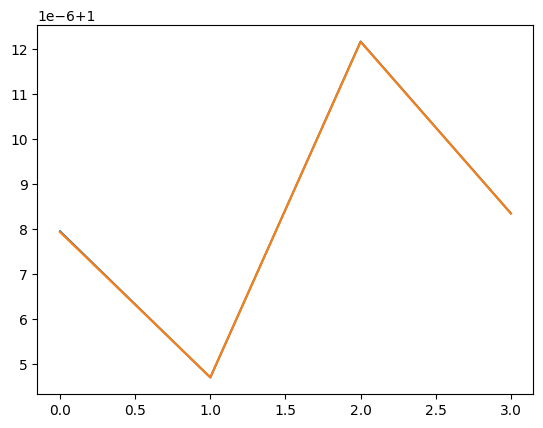

In [141]:
print(true_k)
print(resJ_vec.x)
print(resL_vec.x)
plt.plot(true_k/resJ_vec.x)
plt.plot(true_k/resL_vec.x)
plt.show();

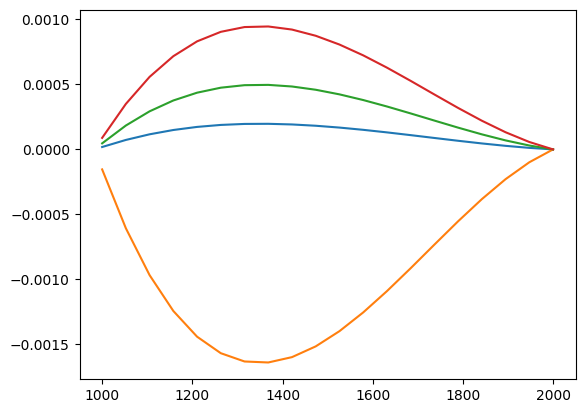

In [148]:
k_lami = []
for lam in range(len(lam_range)):
    resJ_vec = minimize(chi2J_vec, k_test, method='L-BFGS-B', args=(m_lamij[lam,:,:], sig_ij, sigk))
    k_lami.append(resJ_vec.x)
k_lami = np.array(k_lami)

for i in range(Nexp):
    plt.plot(lam_range, k_lami[:,i])
# plt.plot(lam_range, rescaled)
plt.show()